<a href="https://colab.research.google.com/github/murtaza2k/AI_Residency/blob/main/LLMandVectorEmbedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LLM Memory & Vector Embeddings: A Beginner’s Guide

Vector Embeddings: Turning Words into Numbers

    Concept

    Computers cannot understand text directly.

    So we convert words into vectors (lists of numbers).

    Example:

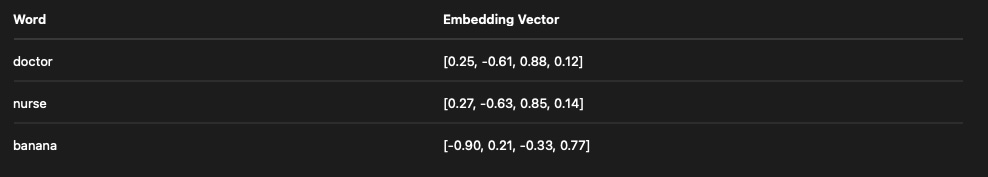

In [4]:
#Simple Python Example
!pip install sentence-transformers

In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "doctor treats patients",
    "nurse helps patients",
    "banana is a fruit"
]

embeddings = model.encode(sentences)

for sentence, vector in zip(sentences, embeddings):
    print(sentence)
    print(vector[:10])  # first 10 numbers

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

doctor treats patients
[-0.02023798  0.09338269  0.02226429  0.00320735 -0.10759626 -0.07928877
  0.0422857   0.06150755 -0.00419385 -0.04280709]
nurse helps patients
[-0.04972363 -0.00469225 -0.00700815  0.01678108 -0.0460837   0.03548325
  0.03851915  0.0092297  -0.02524187 -0.08445646]
banana is a fruit
[ 0.01275797  0.02092094 -0.0117286   0.01683295 -0.00033421  0.06774574
  0.07804267 -0.00828382  0.02563256  0.07950574]


Measuring Similarity

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity([embeddings[0]], [embeddings[1]])
print("Similarity: Doctor vs Nurse", sim)
sim = cosine_similarity([embeddings[0]], [embeddings[2]])
print("Similarity: Doctor vs Banana", sim)


Similarity: Doctor vs Nurse [[0.6018373]]
Similarity: Doctor vs Banana [[0.04227757]]


Intermediate Example: Word Similarity

In [9]:
words = [
    "doctor",
    "physician",
    "hospital",
    "car",
    "banana"
]

emb = model.encode(words)

for i in range(len(words)):
    for j in range(i+1, len(words)):
        sim = cosine_similarity([emb[i]], [emb[j]])[0][0]
        print(words[i], words[j], sim)

doctor physician 0.8598131
doctor hospital 0.5971127
doctor car 0.36081612
doctor banana 0.33794543
physician hospital 0.527017
physician car 0.28424305
physician banana 0.20846672
hospital car 0.2464447
hospital banana 0.22231552
car banana 0.3898862


Advanced Example: Document Embeddings

In [10]:
documents = [
"Cardiology deals with heart diseases",
"Neurology focuses on brain disorders",
"Pediatrics treats children",
"Apple and banana are fruits"
]

doc_embeddings = model.encode(documents)

In [11]:
print(doc_embeddings)

[[ 0.02276961  0.04234028 -0.06766213 ...  0.06622307  0.12861933
   0.04300002]
 [ 0.05218738 -0.04383809 -0.06008127 ...  0.12075084  0.05452261
  -0.04098977]
 [-0.03776491  0.08200591  0.03761283 ...  0.0586735   0.09724064
   0.0995974 ]
 [ 0.04104044  0.00567967 -0.01111601 ... -0.05458344  0.09442026
   0.02908395]]


Basic Semantic Search Example

In [ ]:
documents = [
"Cardiology deals with heart diseases",
"Neurology treats brain disorders",
"Dermatology treats skin conditions",
"Pediatrics cares for children"
]

doc_embeddings = model.encode(documents)

query = "heart doctor"

query_embedding = model.encode([query])
print(query_embedding)

In [13]:
scores = cosine_similarity(query_embedding, doc_embeddings)[0]

for score, doc in sorted(zip(scores, documents), reverse=True):
    print(score, doc)

0.6633843 Cardiology deals with heart diseases
0.22155932 Pediatrics cares for children
0.1706236 Dermatology treats skin conditions
0.11971183 Neurology treats brain disorders


Intermediate: Building a Mini Search Engine

In [15]:
knowledge_base = [
"Heart attack symptoms include chest pain",
"Brain stroke affects blood supply",
"Diabetes affects blood sugar",
"Flu causes fever and cough"
]

embeddings = model.encode(knowledge_base)

def semantic_search(query):

    q = model.encode([query])
    scores = cosine_similarity(q, embeddings)[0]

    best = sorted(zip(scores, knowledge_base), reverse=True)

    return best[:2]

print(semantic_search("heart pain"))

[(np.float32(0.66245353), 'Heart attack symptoms include chest pain'), (np.float32(0.12377462), 'Brain stroke affects blood supply')]
